In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.naive_bayes import GaussianNB
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['font.size'] = 12
from sklearn.metrics import accuracy_score,f1_score,classification_report,precision_score,recall_score,roc_auc_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import ConfusionMatrixDisplay

# Data Preprocessing

* **Train-Test Split:** The data was split into 80% training and 20% testing using stratified sampling.
* **Invalid Values:** Zero values in `RestingBP` and `Cholesterol` were treated as missing values.
* **Imputation:** Missing values were replaced using the **median calculated from the training set** to avoid data leakage.
* **Encoding:** Categorical variables were converted into numerical features using **One-Hot Encoding**.
* **Scaling:** Numerical features were standardized using **StandardScaler**, fitted only on the training data.


In [2]:
df = pd.read_csv("heart.csv")

df_raw = df.copy()

In [3]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [4]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {n_duplicates}")

Number of duplicate rows found: 0


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
ChestPainType_dummies = pd.get_dummies(
    df['ChestPainType'],
    prefix='ChestPainType',
    drop_first=True,
    dtype=int
)

df = pd.concat([df, ChestPainType_dummies], axis=1)

In [8]:
RestingECG_dummies = pd.get_dummies(
    df['RestingECG'],
    prefix='RestingECG',
    drop_first=True,
    dtype=int
)

df = pd.concat([df,RestingECG_dummies ], axis=1)

In [9]:
ST_Slope_dummies = pd.get_dummies(
    df['ST_Slope'],
    prefix='ST_Slope',
    drop_first=True,
    dtype=int
)

df = pd.concat([df,ST_Slope_dummies],axis=1)

In [10]:
df = df.drop(['ChestPainType','RestingECG','ST_Slope'],axis=1)

In [11]:

df['Sex'] = df['Sex'].map({
    'M': 0,
    'F': 1
})


df['ExerciseAngina'] = df['ExerciseAngina'].map({
    'N': 0,
    'Y': 1
})

In [12]:
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,1,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,0,130,283,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,1,138,214,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,0,150,195,0,122,0,0.0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,1,0,0,1,1,0,1,0
914,68,0,144,193,1,141,0,3.4,1,0,0,0,1,0,1,0
915,57,0,130,131,0,115,1,1.2,1,0,0,0,1,0,1,0
916,57,1,130,236,0,174,0,0.0,1,1,0,0,0,0,1,0


In [13]:

df["MaxHR_Ratio"] = df["MaxHR"] / (220 - df["Age"])

x = df.drop("HeartDisease",axis=1)
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42
)

In [14]:
for col in X_train.columns:
  print(f"{col} : {((X_train[col]==0).sum())}")

Age : 0
Sex : 579
RestingBP : 0
Cholesterol : 129
FastingBS : 566
MaxHR : 0
ExerciseAngina : 434
Oldpeak : 304
ChestPainType_ATA : 598
ChestPainType_NAP : 579
ChestPainType_TA : 694
RestingECG_Normal : 287
RestingECG_ST : 593
ST_Slope_Flat : 360
ST_Slope_Up : 421
MaxHR_Ratio : 0


In [15]:
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

invalid_zero_columns = ["RestingBP","Cholesterol"]

for col in invalid_zero_columns:

    X_train_imp[col] = X_train_imp[col].replace(0,np.nan)
    X_test_imp[col] = X_test_imp[col].replace(0,np.nan)

In [16]:
medians_train = X_train_imp[invalid_zero_columns].median()

X_train_imp[invalid_zero_columns] = X_train_imp[invalid_zero_columns].fillna(medians_train)
X_test_imp[invalid_zero_columns] = X_test_imp[invalid_zero_columns].fillna(medians_train)

In [17]:
for col in X_train_imp.columns:
  print(f"{col} : {((X_train_imp[col]==0).sum())}")

Age : 0
Sex : 579
RestingBP : 0
Cholesterol : 0
FastingBS : 566
MaxHR : 0
ExerciseAngina : 434
Oldpeak : 304
ChestPainType_ATA : 598
ChestPainType_NAP : 579
ChestPainType_TA : 694
RestingECG_Normal : 287
RestingECG_ST : 593
ST_Slope_Flat : 360
ST_Slope_Up : 421
MaxHR_Ratio : 0


# EDA

## 1. Heart Disease Distribution

- 508 patients (55.3%) have Heart Disease.
- 410 patients (44.7%) do not have Heart Disease.
- Therefore, the dataset is relatively balanced, with only a slight difference between the two classes.

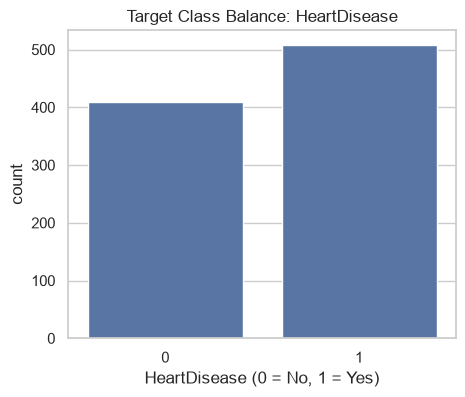

HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64

In [18]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="HeartDisease")
plt.title("Target Class Balance: HeartDisease")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.show()

df["HeartDisease"].value_counts(normalize=True).mul(100).round(1)

## 2. Age Distribution
- Patients' ages range approximately from 28 to 77 years.
- Most observations are concentrated around the middle-age range (approximately 45–60).

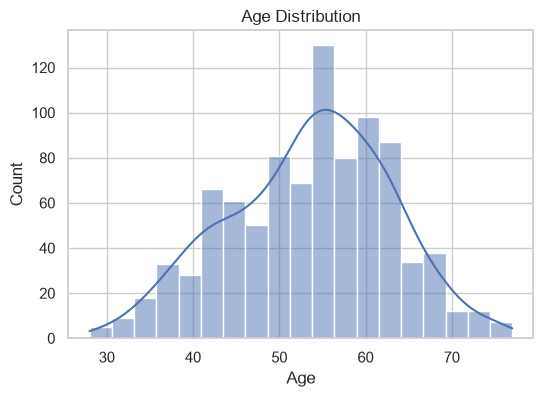

In [19]:
sns.histplot(
    data=df,
    x='Age',
    kde=True
)

plt.title("Age Distribution")
plt.show()

## 3. Numerical Features
- Some features contain outliers, especially Cholesterol, RestingBP, and Oldpeak.
- Cholesterol shows relatively high variability and several extreme values.
- We did not automatically remove the outliers because they may represent valid medical observations.

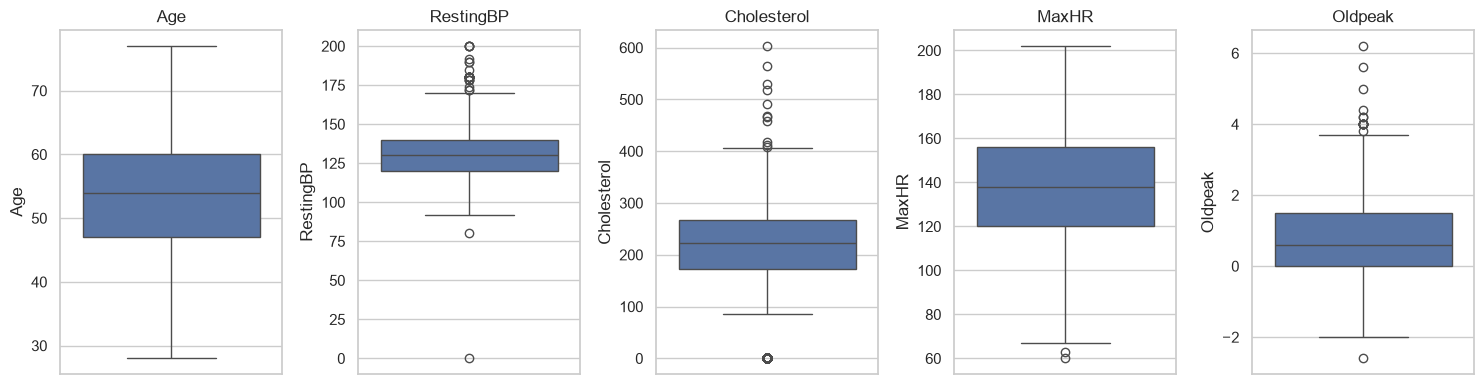

In [20]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 4))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [21]:
numeric_cols = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak'
]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers))

Age : 0
RestingBP : 28
Cholesterol : 183
MaxHR : 2
Oldpeak : 16


## 4. Age vs Heart Disease — Boxplot

- Patients with Heart Disease tend to be older than patients without Heart Disease.
- This suggests that Age is an important feature for predicting Heart Disease.

## 5. MaxHR vs Heart Disease — Boxplot

- Patients with Heart Disease tend to have a lower maximum heart rate (MaxHR) compared with patients without Heart Disease.
- This indicates a potential relationship between MaxHR and Heart Disease.

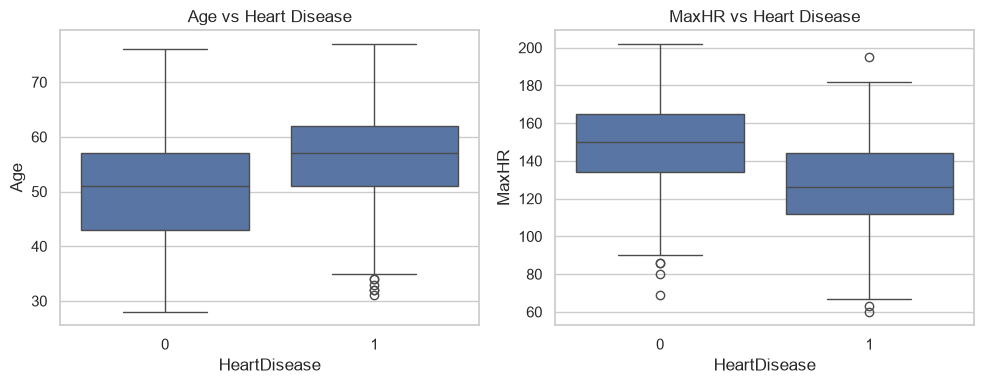

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=df, x='HeartDisease', y='Age', ax=axes[0])
axes[0].set_title("Age vs Heart Disease")

sns.boxplot(data=df, x='HeartDisease', y='MaxHR', ax=axes[1])
axes[1].set_title("MaxHR vs Heart Disease")

plt.tight_layout()
plt.show()


## 6. Chest Pain Type vs Heart Disease

- Chest Pain Type shows a clear relationship with Heart Disease.
- ASY (Asymptomatic) is much more common among patients with Heart Disease.
- ATA appears more frequently among patients without Heart Disease.

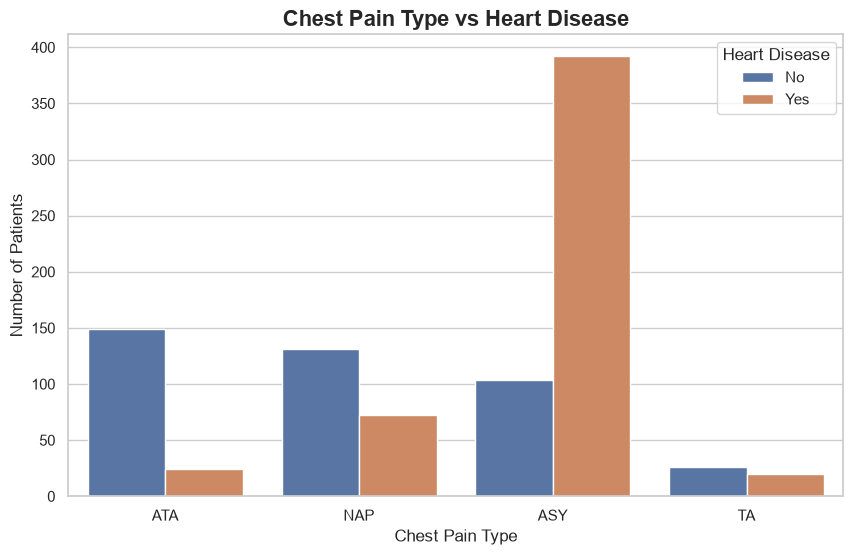

In [23]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df_raw,
    x='ChestPainType',
    hue='HeartDisease'
)

plt.title(
    "Chest Pain Type vs Heart Disease",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")

plt.legend(
    title="Heart Disease",
    labels=["No","Yes"]
)

plt.show()

## 7. Exercise Angina vs Heart Disease Rate
 Heart disease rate is significantly higher in patients with exercise angina (85% vs. 35%).

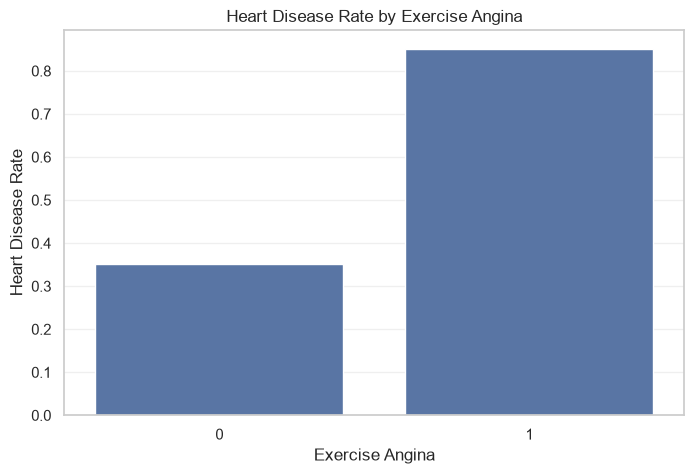

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="ExerciseAngina",
    y="HeartDisease",
    errorbar=None
)

plt.title("Heart Disease Rate by Exercise Angina")
plt.xlabel("Exercise Angina")
plt.ylabel("Heart Disease Rate")

plt.grid(axis="y", alpha=0.3)
plt.show()

## 8. ST Slope vs Heatr Disease Rate
 Flat and Down slopes show a much higher heart disease rate (83% and 78%) compared to Up (20%).

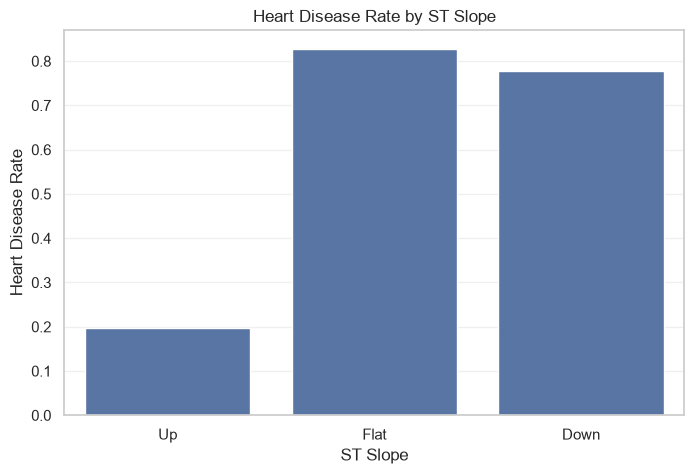

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_raw,
    x="ST_Slope",
    y="HeartDisease",
    errorbar=None
)

plt.title("Heart Disease Rate by ST Slope")
plt.xlabel("ST Slope")
plt.ylabel("Heart Disease Rate")

plt.grid(axis="y", alpha=0.3)
plt.show()

## 9. Correlation Heatmap
- Oldpeak shows a moderate positive correlation with heart disease (0.40), while MaxHR shows a moderate negative correlation (-0.40).
- Age (0.28) and FastingBS (0.27) have weak-to-moderate positive correlations, whereas Cholesterol (-0.23) has a weak negative correlation and RestingBP (0.11) has a very weak positive correlation.

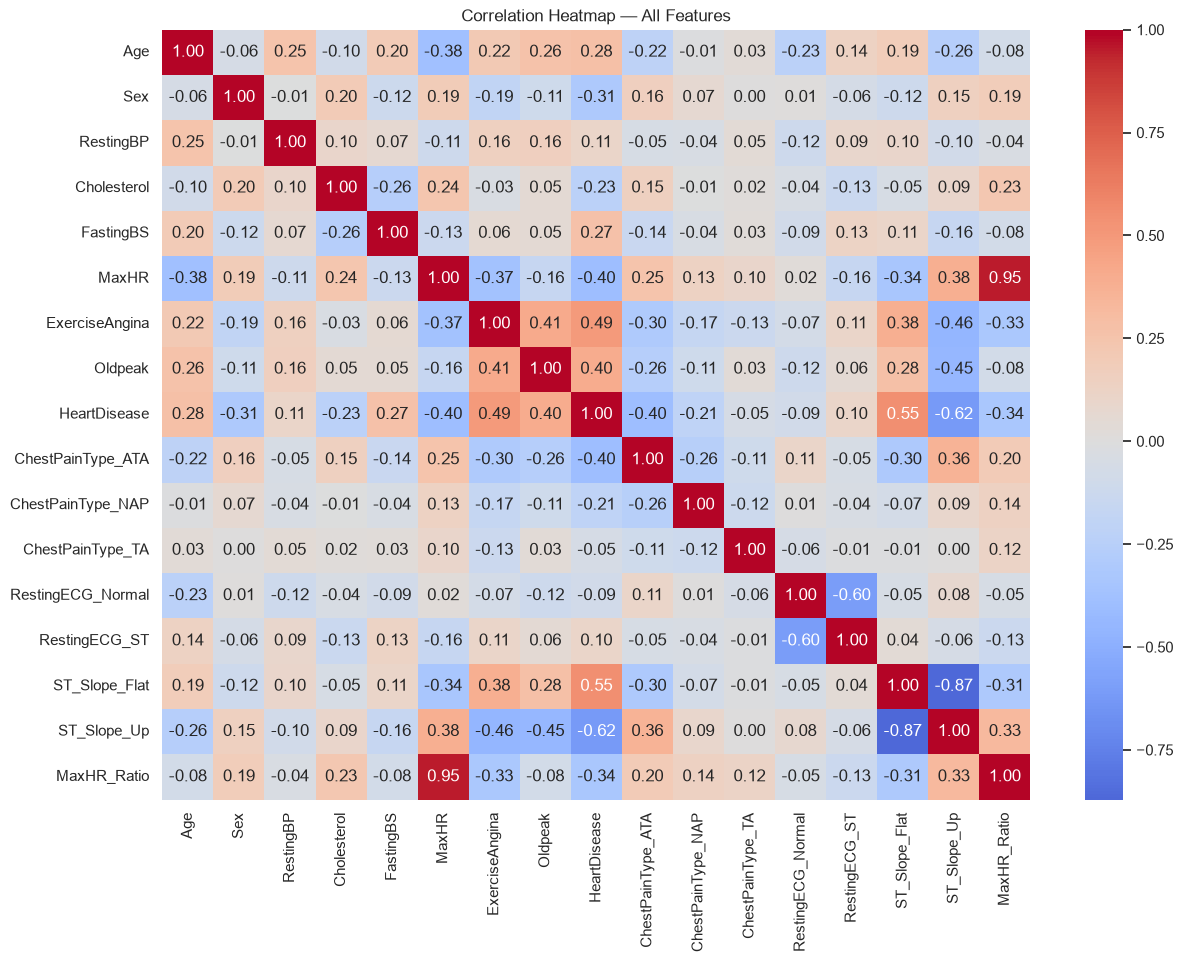

In [26]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — All Features")
plt.show()

In [27]:
heart_corr = df.corr(numeric_only=True)["HeartDisease"].drop("HeartDisease")

heart_corr = heart_corr.sort_values(ascending=False)

heart_corr

ST_Slope_Flat        0.554134
ExerciseAngina       0.494282
Oldpeak              0.403951
Age                  0.282039
FastingBS            0.267291
RestingBP            0.107589
RestingECG_ST        0.102527
ChestPainType_TA    -0.054790
RestingECG_Normal   -0.091580
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
Sex                 -0.305445
MaxHR_Ratio         -0.335320
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164
Name: HeartDisease, dtype: float64

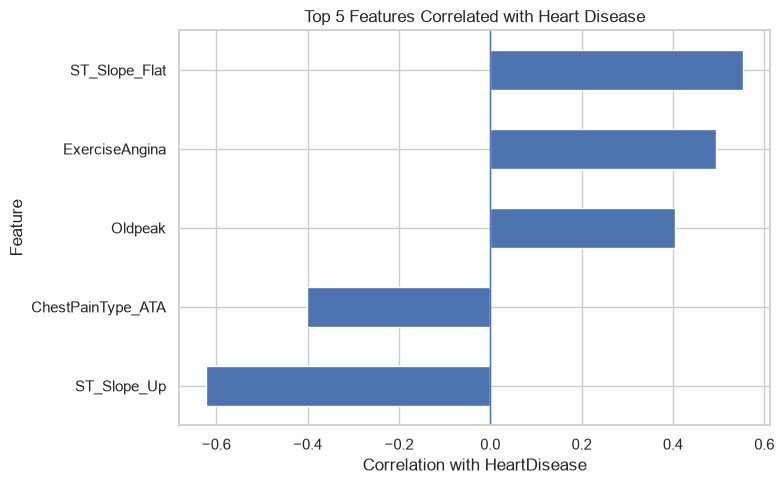

In [28]:
top_corr = heart_corr.abs().sort_values(ascending=False).head(5)

top_features = heart_corr.loc[top_corr.index]

plt.figure(figsize=(8, 5))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 5 Features Correlated with Heart Disease")
plt.xlabel("Correlation with HeartDisease")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

# Models

In [29]:
scaler = StandardScaler()
X_train_scaled = X_train_imp.copy()
X_test_scaled = X_test_imp.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_imp[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test_imp[numeric_cols])
X_train_scaled.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,MaxHR_Ratio
485,0.970012,0,0.339016,-0.517499,1,-0.324520,1,0.317046,1,0,0,0,1,1,0,0.815287
486,0.122028,0,-1.266031,-0.572835,1,1.689837,0,-0.440356,1,0,0,0,1,0,1,1.090909
117,0.546020,1,-0.159102,1.714383,1,-0.247045,1,0.601071,0,0,0,0,1,1,0,0.807453
361,-0.725956,0,1.501291,-0.130147,0,-0.479470,1,-0.819056,0,0,0,1,0,1,0,0.716763
296,-0.407962,0,0.671094,-0.130147,1,0.101594,1,-0.156330,0,0,0,1,0,1,0,0.817647


## Decision Tree Model

In [30]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Test Precision:", precision_score(y_test, y_pred_dt))
print("Test Recall:", recall_score(y_test, y_pred_dt))
print("Test F1:", f1_score(y_test, y_pred_dt))
print("DT ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Test Accuracy: 0.7336956521739131
Test Precision: 0.7676767676767676
Test Recall: 0.7450980392156863
Test F1: 0.7562189054726368
DT ROC-AUC: 0.7323051171688187

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        82
           1       0.77      0.75      0.76       102

    accuracy                           0.73       184
   macro avg       0.73      0.73      0.73       184
weighted avg       0.73      0.73      0.73       184



## Random Forest Model

In [31]:
rf_model = RandomForestClassifier(

    random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt"
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test Precision:", precision_score(y_test, y_pred_rf))
print("Test Recall:", recall_score(y_test, y_pred_rf))
print("Test F1:", f1_score(y_test, y_pred_rf))
print("RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Test Accuracy: 0.8315217391304348
Test Precision: 0.8514851485148515
Test Recall: 0.8431372549019608
Test F1: 0.8472906403940886
RF ROC-AUC: 0.9110473457675753

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81        82
           1       0.85      0.84      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



## Logistic Regression Model

In [32]:
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Test Precision:", precision_score(y_test, y_pred_lr))
print("Test Recall:", recall_score(y_test, y_pred_lr))
print("Test F1:", f1_score(y_test, y_pred_lr))
print("LR ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Test Accuracy: 0.8913043478260869
Test Precision: 0.8942307692307693
Test Recall: 0.9117647058823529
Test F1: 0.9029126213592233
LR ROC-AUC: 0.9329268292682926

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



## SVM(RBF)

In [33]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.1}
Best CV F1: 0.8816454026465046


c:\Users\Legion\OneDrive\Documents\SIC8\Tasks\SIC\depi\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [34]:
svm_best = svm_grid.best_estimator_

y_pred_svm = svm_best.predict(X_test_scaled)
y_prob_svm = svm_best.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Test Precision:", precision_score(y_test, y_pred_svm))
print("Test Recall:", recall_score(y_test, y_pred_svm))
print("Test F1:", f1_score(y_test, y_pred_svm))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Test Accuracy: 0.8586956521739131
Test Precision: 0.88
Test Recall: 0.8627450980392157
Test F1: 0.8712871287128713
Test ROC-AUC: 0.9349593495934959


## Gradient Boosting

In [35]:
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)


gb_grid.fit(X_train, y_train)

print("Best Parameters:",gb_grid.best_params_)
print("Best CV F1:",gb_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1: 0.8918225645697445


In [36]:
gb_best = gb_grid.best_estimator_

y_pred_gb = gb_best.predict(X_test)
y_prob_gb = gb_best.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Test Precision:", precision_score(y_test, y_pred_gb))
print("Test Recall:", recall_score(y_test, y_pred_gb))
print("Test F1:", f1_score(y_test, y_pred_gb))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Test Accuracy: 0.875
Test Precision: 0.8910891089108911
Test Recall: 0.8823529411764706
Test F1: 0.8866995073891626
Test ROC-AUC: 0.926231468197035


## KNN

In [37]:
knn = KNeighborsClassifier()

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    estimator=knn,
    param_grid=knn_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best CV F1:", knn_grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV F1: 0.8802270048411909


In [38]:
knn_best = knn_grid.best_estimator_

y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Test Precision:", precision_score(y_test, y_pred_knn))
print("Test Recall:", recall_score(y_test, y_pred_knn))
print("Test F1:", f1_score(y_test, y_pred_knn))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_knn))

Test Accuracy: 0.8532608695652174
Test Precision: 0.8865979381443299
Test Recall: 0.8431372549019608
Test F1: 0.864321608040201
Test ROC-AUC: 0.9304758488761359


## XGBoost

In [39]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200, 'subsample': 1.0}
Best CV F1: 0.8908007913956812


In [40]:
xgb_best = xgb_grid.best_estimator_

y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Test Precision:", precision_score(y_test, y_pred_xgb))
print("Test Recall:", recall_score(y_test, y_pred_xgb))
print("Test F1:", f1_score(y_test, y_pred_xgb))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

Test Accuracy: 0.8695652173913043
Test Precision: 0.89
Test Recall: 0.8725490196078431
Test F1: 0.8811881188118812
Test ROC-AUC: 0.930416068866571


# Evaluation

## Evaluation Table

In [41]:
results = {
    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, y_pred_dt),
        "Precision": precision_score(y_test, y_pred_dt),
        "Recall": recall_score(y_test, y_pred_dt),
        "F1": f1_score(y_test, y_pred_dt),
        "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision": precision_score(y_test, y_pred_lr),
        "Recall": recall_score(y_test, y_pred_lr),
        "F1": f1_score(y_test, y_pred_lr),
        "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
    },

    "SVM-RBF": {
        "Accuracy": accuracy_score(y_test, y_pred_svm),
        "Precision": precision_score(y_test, y_pred_svm),
        "Recall": recall_score(y_test, y_pred_svm),
        "F1": f1_score(y_test, y_pred_svm),
        "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
    },

    "Gradient Boosting": {
        "Accuracy": accuracy_score(y_test, y_pred_gb),
        "Precision": precision_score(y_test, y_pred_gb),
        "Recall": recall_score(y_test, y_pred_gb),
        "F1": f1_score(y_test, y_pred_gb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_gb)
    },

    "KNN": {
        "Accuracy": accuracy_score(y_test, y_pred_knn),
        "Precision": precision_score(y_test, y_pred_knn),
        "Recall": recall_score(y_test, y_pred_knn),
        "F1": f1_score(y_test, y_pred_knn),
        "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
    },

    "XGBoost": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb),
        "Precision": precision_score(y_test, y_pred_xgb),
        "Recall": recall_score(y_test, y_pred_xgb),
        "F1": f1_score(y_test, y_pred_xgb),
        "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
    }
}

In [42]:
results_df = pd.DataFrame(results).T

results_df = results_df.round(3)

results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Decision Tree,0.734,0.768,0.745,0.756,0.732
Random Forest,0.832,0.851,0.843,0.847,0.911
Logistic Regression,0.891,0.894,0.912,0.903,0.933
SVM-RBF,0.859,0.880,0.863,0.871,0.935
Gradient Boosting,0.875,0.891,0.882,0.887,0.926
KNN,0.853,0.887,0.843,0.864,0.930
XGBoost,0.870,0.890,0.873,0.881,0.930


## Model Comparison – F1 Score


- **Gradient Boosting** achieved the highest F1-score (**0.909**), followed by XGBoost (**0.904**) and Logistic Regression (**0.903**).
- **Decision Tree** had the lowest F1-score (**0.772**).
- Since the dataset is imbalanced, F1-score is used as an important metric because it balances Precision and Recall.

In [43]:
results_df.sort_values("Recall", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.891,0.894,0.912,0.903,0.933
Gradient Boosting,0.875,0.891,0.882,0.887,0.926
XGBoost,0.870,0.890,0.873,0.881,0.930
SVM-RBF,0.859,0.880,0.863,0.871,0.935
Random Forest,0.832,0.851,0.843,0.847,0.911
KNN,0.853,0.887,0.843,0.864,0.930
Decision Tree,0.734,0.768,0.745,0.756,0.732


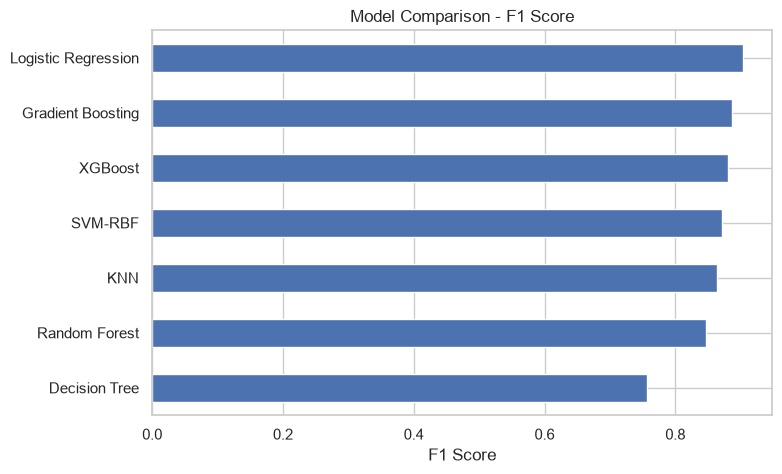

In [44]:
results_df["F1"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("F1 Score")
plt.show()

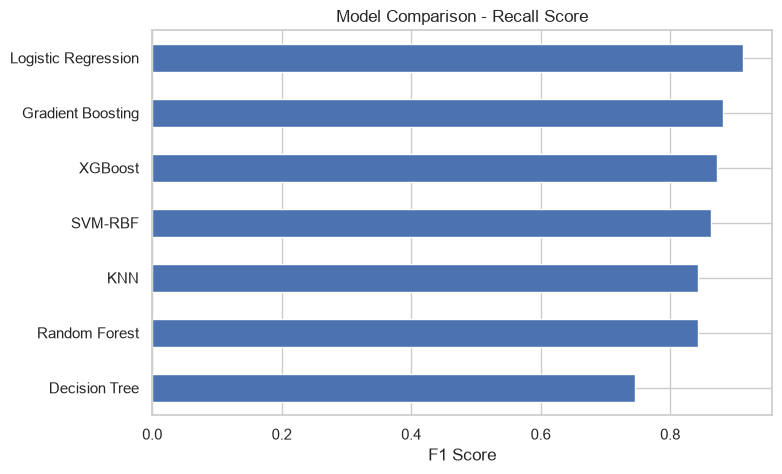

In [45]:
results_df["Recall"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Model Comparison - Recall Score")
plt.xlabel("F1 Score")
plt.show()

## Confusion Metric for Top Performing models

- **Gradient Boosting:** Detects the most positive cases with **100 TP** and only **2 FN**, but has **37 FP**.
- **XGBoost:** Shows very similar performance, with **100 TP**, **2 FN**, and slightly fewer **36 FP**.
- **Logistic Regression:** Produces fewer false positives (**11 FP**) and more true negatives (**71 TN**), but misses more positive cases (**9 FN**).

Overall, **Gradient Boosting and XGBoost are better at minimizing false negatives**, while Logistic Regression provides a better balance in reducing false positives. Since the dataset is imbalanced and the problem focuses on **heart disease detection**, minimizing false negatives is particularly important.

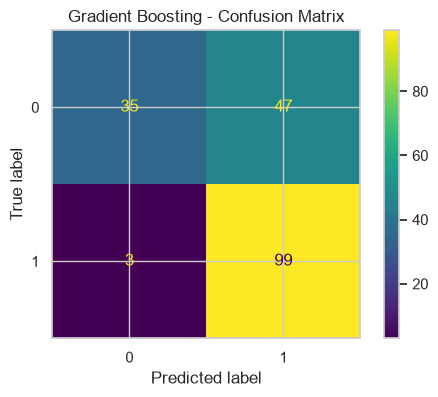

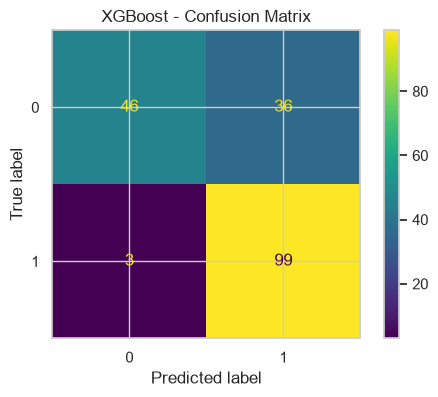

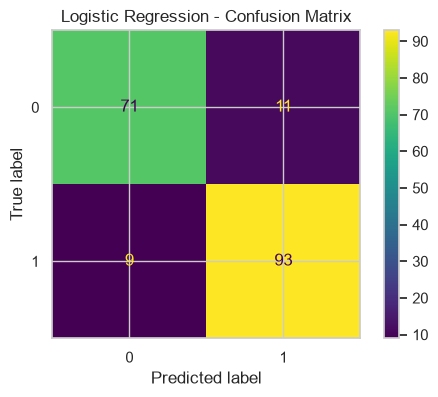

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Gradient Boosting": gb_best,
    "XGBoost": xgb_best,
    "Logistic Regression": lr_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

## ROC-AUC Comparison

- **SVM-RBF** achieved the highest ROC-AUC (**0.935**).
- Logistic Regression, Gradient Boosting, and XGBoost also achieved strong ROC-AUC scores of approximately **0.93**.
- **Decision Tree** had the lowest ROC-AUC (**0.748**).
- The top models show very similar discrimination ability, so ROC-AUC alone was not used to select the final model.

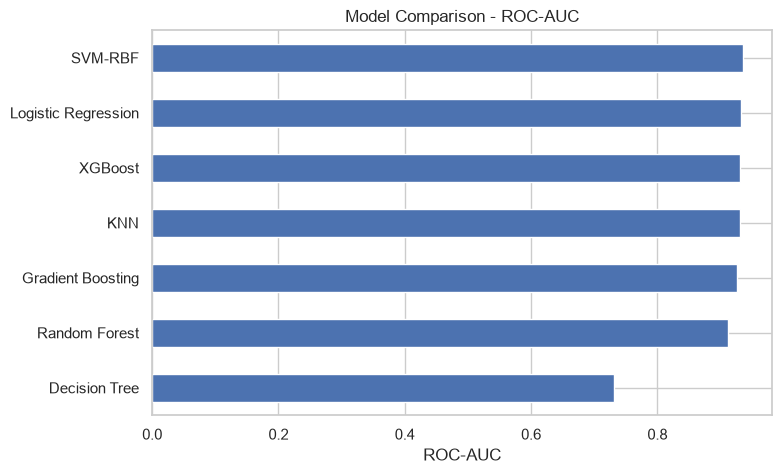

In [47]:
results_df["ROC-AUC"].sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Model Comparison - ROC-AUC")
plt.xlabel("ROC-AUC")
plt.show()

# Decision

## Gradient Boosting was selected as the final model
 because the dataset is imbalanced and the application involves heart disease prediction, where **minimizing false negatives** is particularly important. It achieved the highest F1-score (0.909) and recall (0.931), detecting 100 positive cases while missing only 2. Although Logistic Regression produced fewer false positives, it missed 9 positive cases. Therefore, Gradient Boosting provides the most suitable performance for prioritizing the detection of heart disease cases.